# 01. Multi-band forced photometry on Euclid Q1 data

Measure fluxes for a MER-selected source list in VIS, NISP (Y, J, H),
and optionally unWISE (W1, W2), then assemble a catalog with estimated
uncertainties, AB magnitudes, and quality flags. This example covers
200 arcsec in the Euclid Deep Field North, within one MER tile.

VIS supplies the highest-resolution image (about 0.2 arcsec FWHM).
We fit source positions and smooth profiles on VIS, then hold those
models fixed while fitting fluxes on NISP (about 0.5 arcsec) and
unWISE (about 6–7 arcsec). This assumes that the source morphology
is shared across bands; color gradients or infrared-only components
can violate that assumption.

This notebook uses MER sources and the VIS model-selection tree.
`model_selection="prior"` instead uses the MER classifications and
shape parameters. Bright-star and invalid pixels are excluded from
Euclid fitting; quality flags identify some remaining affected sources.


## 1. Setup, target, and configuration

A 200 arcsec region of EDF-N with roughly a thousand MER sources.


In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()
                     and (p / "pyproject.toml").is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from inside the project directory.")
loaded = sys.modules.get("euclid_phot")
if loaded is not None and Path(loaded.__file__).resolve().parent != PROJECT_ROOT / "src/euclid_phot":
    raise RuntimeError("Restart the kernel to use this project's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))


In [2]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.stats import mad_std
from astropy.table import Table

import euclid_phot as ep

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 17,
})

TARGET_RA = 269.48
TARGET_DEC = 67.30
CUTOUT_SIZE_ARCSEC = 200.0


DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/native_data"))

# MER sources with tree-selected or catalog-prior VIS models.
# refine_positions controls an additional centroid fit after model selection.
PRIOR = {
    "band": "VIS",
    "objects": "mer",
    "model_selection": "tree",
    "free_shapes": True,    # ignored on the tree path: shapes fit per blob
    "refine_positions": False,
}

# Bright-star pixel mask for the prior-band fit
MASK_BRIGHT_STARS = True

# Bands the prior fit is propagated to.
TARGET_BANDS = {
    "euclid": ("Y", "J", "H"),
    "wise":   ("W1", "W2"),
}

if PRIOR["band"] != "VIS" or PRIOR["objects"] != "mer":
    raise ValueError("This notebook uses VIS with a MER source list.")
if PRIOR["model_selection"] not in ("tree", "prior"):
    raise ValueError("Choose model_selection='tree' or 'prior'.")
if tuple(TARGET_BANDS["euclid"]) != ("Y", "J", "H"):
    raise ValueError("This notebook fits Y, J, and H together.")
if tuple(TARGET_BANDS["wise"]) not in ((), ("W1", "W2")):
    raise ValueError("Choose W1 and W2 together, or () to skip WISE.")

# Worker count for the cutout fetch, the per-band NISP fits, and the
# per-blob tree fits.
N_WORKERS = 10

print(f"Target: RA={TARGET_RA}, Dec={TARGET_DEC}")
print(f"Cutout: {CUTOUT_SIZE_ARCSEC:.0f} arcsec on a side")
print(f"Prior: band={PRIOR['band']}, objects={PRIOR['objects']!r}, "
      f"model_selection={PRIOR['model_selection']!r}")
print(f"Target Euclid bands: {TARGET_BANDS['euclid']}")
print(f"Target WISE bands:   {TARGET_BANDS['wise']}")
print(f"Parallel workers:    {N_WORKERS}")


Target: RA=269.48, Dec=67.3
Cutout: 200 arcsec on a side
Prior: band=VIS, objects='mer', model_selection='tree'
Target Euclid bands: ('Y', 'J', 'H')
Target WISE bands:   ('W1', 'W2')
Parallel workers:    10


## 2. Pipeline overview

Retrieve the catalog, images, and PSFs; build and fit VIS source models;
fit their fluxes in NISP and unWISE; then assemble the catalog and diagnostics.


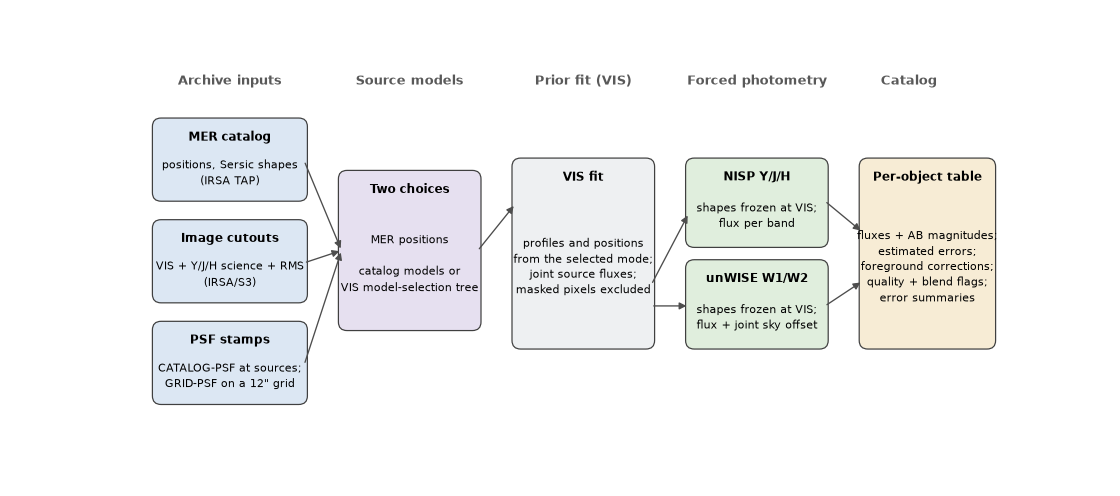

In [3]:
ep.viz.plot_workflow()
plt.show()


## 3. The MER catalog

The MER catalog supplies positions, point-likeness probabilities, and
available Sérsic parameters. This query selects rows with positive VIS
PSF flux. It reads the cached subset when present and queries IRSA otherwise.


In [4]:
mer_path = DATA_DIR / f"mer_catalog_{TARGET_RA:.4f}_{TARGET_DEC:.4f}_{int(CUTOUT_SIZE_ARCSEC)}.fits"
if mer_path.exists():
    mer_cat = Table.read(mer_path)
    print(f"loaded {len(mer_cat)} sources from {mer_path.name}")
else:
    half_size_deg = CUTOUT_SIZE_ARCSEC / 2.0 / 3600.0
    mer_cat = ep.query_mer_catalog(TARGET_RA, TARGET_DEC, half_size_deg)
    print(f"queried IRSA TAP: {len(mer_cat)} sources")


loaded 1120 sources from mer_catalog_269.4800_67.3000_200.fits


## 4. Fetching the Euclid cutouts

`fetch_cutout` copies the requested pixels from one MER tile and keeps
its pixel grid. Science, RMS and flags use the same tile as the PSFs.
The results are cached locally. A field extending beyond the selected
tile needs separate tile fits.

All four delivered MER mosaics have 0.1 arcsec pixels. Their PSFs differ:
about 0.2 arcsec FWHM in VIS and 0.5 arcsec in NISP.


In [5]:
# Retrieve each band's science, RMS, and pixel-quality planes.
cutouts = {}
for band in ('VIS', 'Y', 'J', 'H'):
    cutouts[band] = ep.fetch_cutout(
        band, TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC,
        data_dir=DATA_DIR / "cutouts",
        with_flag=True)

for band, c in cutouts.items():
    print(f"  {band}: shape={c.shape}, pixel scale={c.pixel_scale_arcsec:.3f} arcsec/pix")

# Keep every source whose center lands on the image. A boundary
# source's profile is clipped by the cutout (its photometry carries the
# `edge` flag, section 11), but its light must stay in the model:
# removed, it would be absorbed by whichever neighbors the fit can reach.
mer_cat = ep.trim_catalog_to_cutout(
    mer_cat, cutouts['VIS'].wcs, cutouts['VIS'].shape)
print(f"\non the image: {len(mer_cat)} sources")


  VIS: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  Y: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  J: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  H: shape=(2000, 2000), pixel scale=0.100 arcsec/pix

on the image: 1116 sources


The four bands of the same field, at their native resolutions.


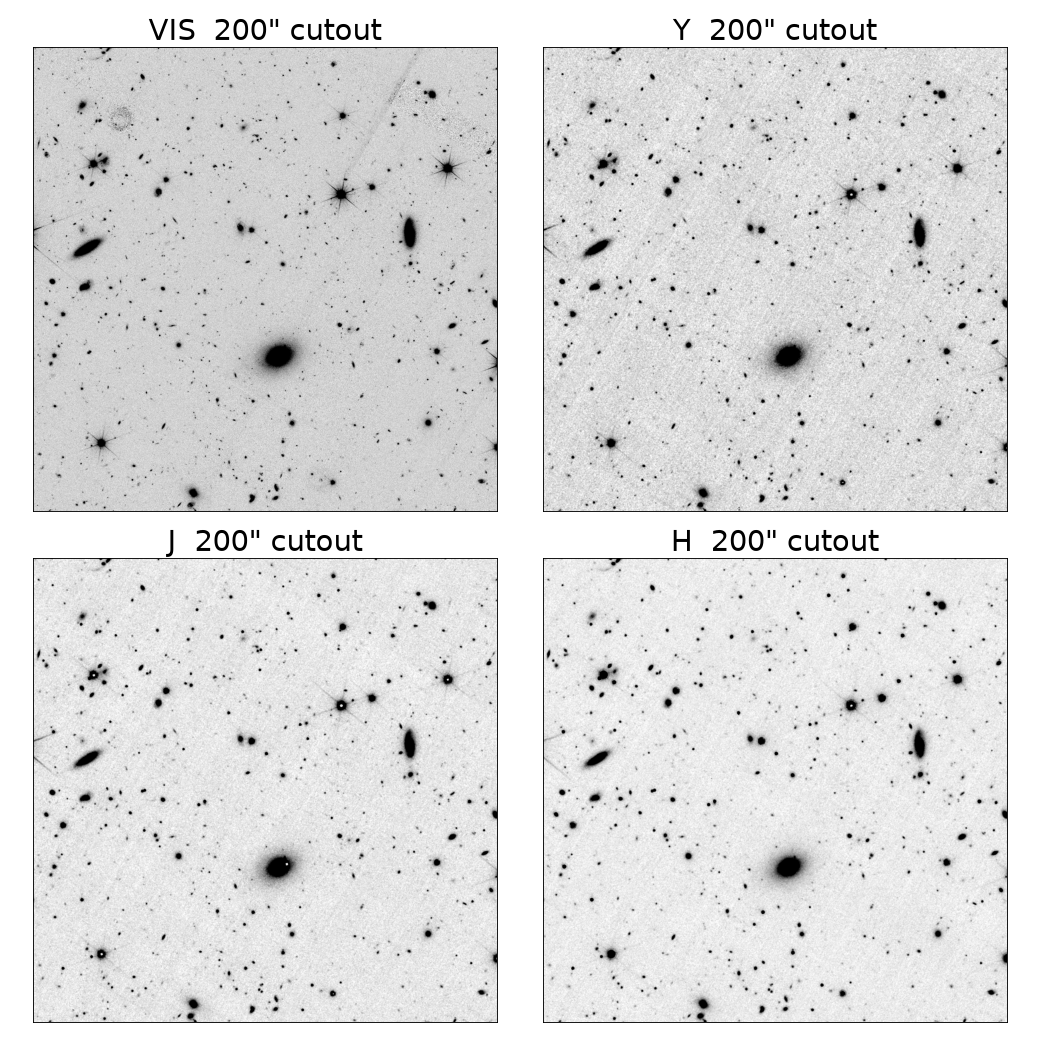

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, band in zip(axes.ravel(), ('VIS', 'Y', 'J', 'H')):
    ep.viz.show_cutout(cutouts[band], ax=ax,
                       title=f"{band}  {CUTOUT_SIZE_ARCSEC:.0f}\" cutout")
    ax.title.set_fontsize(26)
plt.tight_layout(); plt.show()


*These are the delivered MER mosaics on a common 0.1 arcsec grid;
NISP detector pixels are larger. The notebook fits the delivered pixels.*


## 5. The VIS PSF and the Tractor image

GRID-PSF contains samples evaluated on a regular grid; CATALOG-PSF contains
samples evaluated at MER catalogue positions. This tutorial uses GRID in
all Euclid bands. Each source uses its nearest sample, while overlapping
sources are fitted together. To compare products, change `PSF_PRODUCT`
below and restart the notebook; changing products is not a flux calibration.


In [7]:
PSF_PRODUCT = "grid"  # "catalog" is also supported
extract_psf = {"grid": ep.extract_grid_psf, "catalog": ep.extract_catalog_psf}[PSF_PRODUCT]

psf_data_vis = extract_psf(
    "VIS", TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
    tile_id=cutouts["VIS"].header.get("MERTILE"), data_dir=DATA_DIR / "psf")
psf_fwhm_vis = float(np.median(psf_data_vis["fwhm"]))
print(f"VIS {PSF_PRODUCT.upper()}-PSF: {len(psf_data_vis['stamps'])} stamps, "
      f"median FWHM = {psf_fwhm_vis:.3f} arcsec")

# Bright-star footprints (halos and diffraction spikes) carry real
# light the compact PSF stamp cannot model (section 11); read the MER
# STARSIGNAL flag bit as a pixel veto so that light stays out of the fit.
star_mask = ep.starsignal_pixel_mask(cutouts['VIS']) if MASK_BRIGHT_STARS else None
if star_mask is not None:
    print(f"STARSIGNAL bright-star mask: {int(star_mask.sum())} pixels "
          f"({100*star_mask.mean():.2f}%) excluded from the fit")

# build_tractor_image zeroes the inverse variance on the star mask and on
# the coadd-fatal FLG pixels (INVALID/SAT/NO_DATA).
tim_vis = ep.build_tractor_image(
    cutouts['VIS'], psf_data=psf_data_vis, pixel_mask=star_mask)
_flg = cutouts['VIS'].flag
if _flg is not None:
    _nbad = int(((_flg & ep.MER_VIS_BAD_BITS) != 0).sum())
    print(f"VIS FLG plane attached; {_nbad} pixel(s) carry coadd-fatal bits "
          f"(INVALID/SAT/NO_DATA) and are excluded from the fit.")


VIS GRID-PSF: 486 stamps, median FWHM = 0.198 arcsec
STARSIGNAL bright-star mask: 70222 pixels (1.76%) excluded from the fit
VIS FLG plane attached; 2363 pixel(s) carry coadd-fatal bits (INVALID/SAT/NO_DATA) and are excluded from the fit.


### Spatial coverage of the selected PSF samples

The plot shows sample positions, FWHM, and coverage of the cutout. Check
coverage and local variation rather than assuming that every target is
close enough to a representative stamp. Nearest-sample selection does
not interpolate between stamps; very extended sources need extra care.


486 PSF samples, median spacing 12.0 arcsec
FWHM across the field: 0.129-0.221 arcsec (median 0.198)


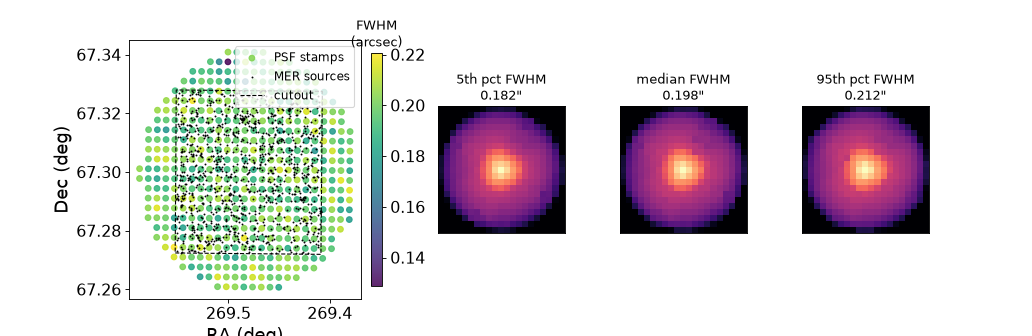

In [8]:
fig, info = ep.viz.show_psf_grid(psf_data_vis, cutout=cutouts['VIS'],
                                 mer_cat=mer_cat)
plt.show()
print(f"{info['n_stamps']} PSF samples, median spacing "
      f"{info['median_spacing_arcsec']:.1f} arcsec")
print(f"FWHM across the field: {info['fwhm_min']:.3f}-"
      f"{info['fwhm_max']:.3f} arcsec (median {info['fwhm_median']:.3f})")


## 6. The source list

`model_selection="prior"` uses a point source when `point_like_prob > 0.96`
or the MER effective radius is smaller than half the VIS PSF FWHM;
otherwise it uses the available MER Sérsic shape, with an exponential fallback.

`model_selection="tree"` fits neighbouring sources together in image
regions detected by SEP. It compares point-source, fixed circular
exponential, exponential, de Vaucouleurs, and composite models using
reduced chi-squared. Resolved models with segment S/N ≥ 20 can also try
a free-index Sérsic model, retained for a total chi-squared improvement > 25.
This is an adaptation of [The Farmer](https://arxiv.org/abs/2310.07757);
[notebook 02](supporting_notebooks/02_model_selection.ipynb) shows the model comparisons.

The tree also refines VIS positions, accepting shifts up to 0.3 arcsec.
A source outside the detected regions retains its MER prior. The output
stays aligned with the input catalog.


In [9]:
t0 = time.time()
if PRIOR["model_selection"] == "tree":
    print("Running the chi-squared decision tree on the prior image...")
    # Compare profile classes jointly with their neighbours on VIS.
    sources_list, _ = ep.run_model_selection(
        mer_cat, tim_vis,
        cutouts[PRIOR["band"]].data, tim_vis.getInvvar(),
        pixscale_arcsec=cutouts[PRIOR["band"]].pixel_scale_arcsec,
        n_workers=N_WORKERS,
    )
    # Rows the tree could not place fall back to their MER prior.
    fallback = ep.build_sources_from_mer(
        mer_cat, band=PRIOR["band"], psf_fwhm_arcsec=psf_fwhm_vis)
    sources = [s if s is not None else fb
               for s, fb in zip(sources_list, fallback)]
else:  # model_selection == "prior"
    print("Using the MER continuous-Sersic catalog priors.")
    sources = ep.build_sources_from_mer(
        mer_cat, band=PRIOR["band"], psf_fwhm_arcsec=psf_fwhm_vis)

class_hist = {}
for s in sources:
    class_hist[type(s).__name__] = class_hist.get(type(s).__name__, 0) + 1
print(f"\nbuilt {len(sources)} sources in {time.time()-t0:.1f} s")
for k in sorted(class_hist):
    print(f"  {k:<22s} {class_hist[k]}")


Running the chi-squared decision tree on the prior image...

built 1116 sources in 246.3 s
  DevGalaxy              114
  ExpGalaxy              508
  FixedCompositeGalaxy   130
  PointSource            210
  SersicGalaxy           138
  SimpleGalaxy           16


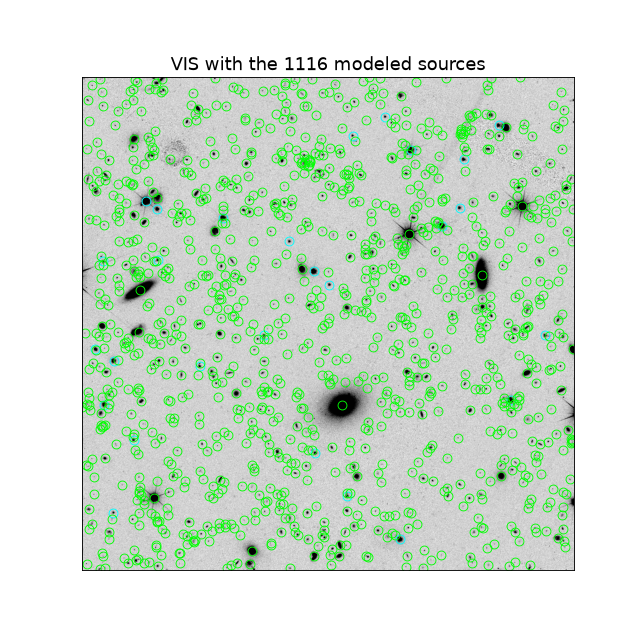

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ep.viz.show_cutout(cutouts['VIS'], mer_cat, ax=ax,
                   title=f"VIS with the {len(sources)} modeled sources")
plt.show()


*The modeled source list over the VIS prior image: cyan circles are
stars, green circles galaxies, following the MER classifier.*


## 7. Step 1: flux-only forced photometry

Freeze positions and shapes, then jointly fit source fluxes. The coarse
`fit_quality` guard rejects negative VIS flux or flux more than 100 times
a positive MER `flux_vis_sersic` reference. It is not a goodness-of-fit test;
an unconstrained source can still pass this guard.


In [11]:
initial_vis_ujy = np.asarray(mer_cat['flux_vis_sersic'], dtype=float)
tractor_vis, fit_quality, vis_err_ujy = ep.fit_forced_photometry(
    tim_vis, sources, band='VIS',
    initial_fluxes_ujy=initial_vis_ujy, return_errors=True,
)
print(f"VIS flux guard passed: {int(fit_quality.sum())}/{len(sources)} sources.")
print(f"median formal 1-sigma flux error (flux-only fit): "
      f"{np.nanmedian(vis_err_ujy[fit_quality]):.3f} microJansky")


VIS flux guard passed: 1107/1116 sources.
median formal 1-sigma flux error (flux-only fit): 0.019 microJansky


## 8. Step 2: free shapes for interior galaxies

For galaxies more than 50 pixels from the cutout edges, the shape
parameters (including the Sersic ``n``) are re-optimized jointly with
brightness; positions remain fixed. The step is skipped when
``free_shapes`` is ``False``, and always in the decision-tree path:
the tree has already fitted each blob's shapes with the bounded
optimizer and shapes stay frozen thereafter.


In [12]:
if PRIOR["free_shapes"] and PRIOR["model_selection"] != "tree":
    fit_quality, n_thawed = ep.fit_free_shapes(
        tractor_vis, tim_vis, sources, fit_quality,
        band=PRIOR["band"], initial_fluxes_ujy=initial_vis_ujy,
    )
    print(f"Step 2 thawed shapes for {n_thawed} galaxies; "
          f"{int(fit_quality.sum())}/{len(sources)} sources pass the VIS flux guard.")
else:
    n_thawed = 0
    reason = ("the decision tree has already fit each blob's shapes with "
              "the bounded optimizer; they stay frozen"
              if PRIOR["model_selection"] == "tree"
              else "PRIOR['free_shapes']=False; shapes stay at the prior")
    print(f"Skipping step 2: {reason}.")

# Optional: a bounded recenter on the prior band. The refined positions live on
# the source objects, so the later NISP/unWISE forced fits measure every band at
# the same recentered position; the multi-band astrometry stays shared.
if PRIOR.get("refine_positions"):
    fit_quality, n_refined, pos_shift_arcsec = ep.refine_positions(
        tractor_vis, tim_vis, sources, fit_quality, band=PRIOR["band"])
    _moved = pos_shift_arcsec[pos_shift_arcsec > 0]
    msg = (f"median shift {np.median(_moved) * 1000:.0f} mas"
           if len(_moved) else "no retained position shift")
    print(f"Refined {n_refined} positions (bounded to 0.2 arcsec); {msg}.")
else:
    pos_shift_arcsec = np.zeros(len(sources))
    print("Additional position refinement off; the selected VIS positions are retained.")
# Measure fluxes and conditional errors at the final positions and shapes.
if n_thawed or PRIOR.get("refine_positions"):
    tractor_vis, final_quality, vis_err_ujy = ep.fit_forced_photometry(
        tim_vis, sources, band="VIS", initial_fluxes_ujy=initial_vis_ujy,
        return_errors=True,
    )
    fit_quality &= final_quality


Skipping step 2: the decision tree has already fit each blob's shapes with the bounded optimizer; they stay frozen.
Additional position refinement off; the selected VIS positions are retained.


## 9. VIS data, model, and residual

The residual is data minus model. Its brightness scale uses the median
formal pixel error; the chi map divides by each pixel's own error.
Correctly standardized noise has unit marginal variance, while pixel
correlations affect spatial structure and flux uncertainties.

Smooth profiles cannot reproduce every arm, bar, or clump. The finite
PSF stamps also omit extended stellar light. Masked pixels are gray;
stellar residuals outside the mask can still affect neighbouring sources.


VIS formal per-pixel sigma:    0.0037457 counts
VIS empirical residual sigma:  0.0023892 counts
VIS chi std:                   0.709


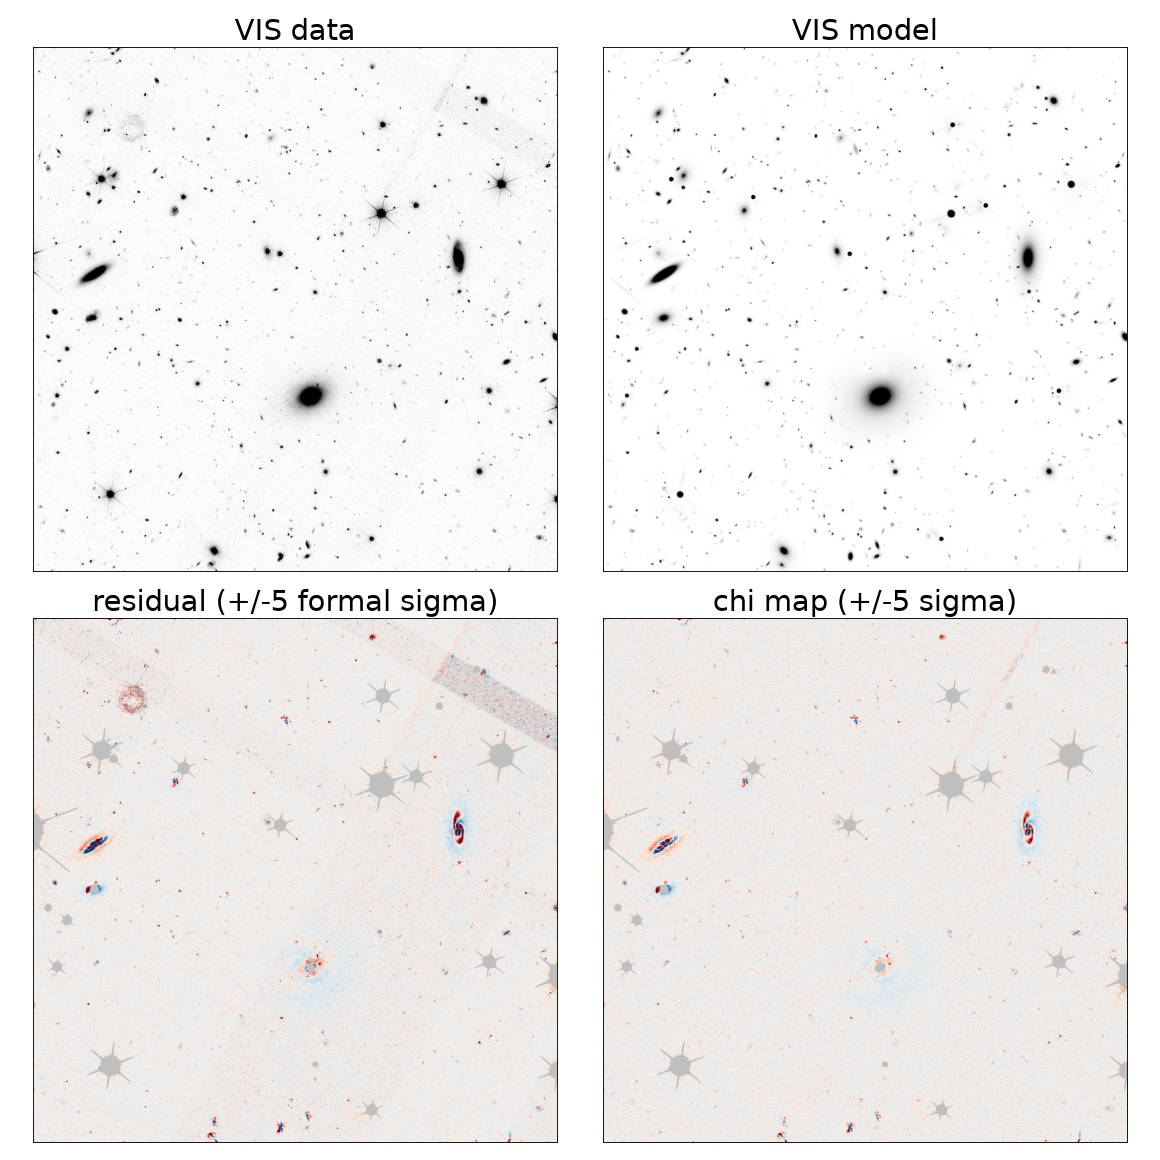

In [13]:
res = ep.measure_residual(tractor_vis, tim_vis)
invvar_vis = tim_vis.getInvvar()

fig, axes = plt.subplots(2, 2, figsize=(14.5, 14.5))
vmax = float(np.nanpercentile(res['data'], 99.5))
axes[0, 0].imshow(res['data'],  origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0, 0].set_title('VIS data')
axes[0, 1].imshow(res['model'], origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0, 1].set_title('VIS model')
_, info_vis_res = ep.viz.show_residual(
    res['data'], res['model'], invvar=invvar_vis,
    ax=axes[1, 0], title='residual (+/-5 formal sigma)')
_, info_vis_chi = ep.viz.show_chi_map(
    res['data'], res['model'], invvar_vis,
    ax=axes[1, 1], title='chi map (+/-5 sigma)')
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.title.set_fontsize(26)
plt.tight_layout(); plt.show()

print(f"VIS formal per-pixel sigma:    {info_vis_res['formal_sigma']:.5g} counts")
print(f"VIS empirical residual sigma:  {info_vis_res['residual_std']:.5g} counts")
print(f"VIS chi std:                   {info_vis_chi['chi_std']:.3f}")

## 10. VIS: Tractor versus MER

Compare the fitted VIS flux with MER `flux_vis_psf` for catalog-classified
stars and `flux_vis_sersic` for the other sources. The source classes used
in our fit come from `PRIOR["model_selection"]`. Unconstrained sources are
excluded; sources near bright stars or the cutout edge are shown separately.


galaxies: median(Tractor / MER_sersic) = 1.001  (excluding flagged sources: 1.001, n=996)
median and NMAD of m_Tractor - m_MER in equal-count magnitude bins:
  21.86 mag: median -0.004, NMAD 0.033
  23.06 mag: median +0.005, NMAD 0.037
  23.77 mag: median +0.001, NMAD 0.042
  24.30 mag: median -0.004, NMAD 0.085
  24.68 mag: median -0.010, NMAD 0.095
  24.96 mag: median -0.047, NMAD 0.094
  25.25 mag: median -0.008, NMAD 0.137
  25.49 mag: median +0.005, NMAD 0.132
  25.67 mag: median -0.017, NMAD 0.136
  25.86 mag: median +0.025, NMAD 0.285
  26.09 mag: median -0.003, NMAD 0.246
  26.44 mag: median +0.073, NMAD 0.284


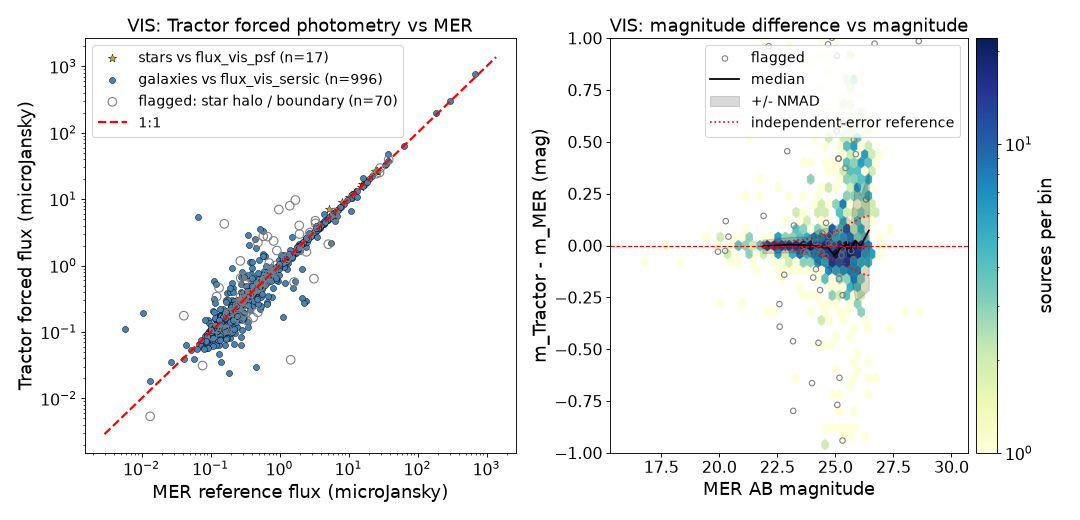

In [14]:
tractor_vis_ujy = np.array(
    [s.brightness.getFlux('VIS') for s in sources]) * 3.631
is_star = np.asarray(mer_cat['is_star'], dtype=bool)
ref_star = np.asarray(mer_cat['flux_vis_psf'],    dtype=float)
ref_gal  = np.asarray(mer_cat['flux_vis_sersic'], dtype=float)

# Bright stars and their close neighbors carry unmodeled spike/halo
# light on both axes, and a source at the cutout boundary is measured
# from a clipped profile; flag both (same flags as section 11) so the
# plot and medians separate them. probable_bright_stars also covers the
# brightest stars, on which the classifier abstains.
flags9 = ep.flag_sources(
    [s.getPosition().ra for s in sources], [s.getPosition().dec for s in sources],
    ref_star, ep.probable_bright_stars(mer_cat),
    wcs=cutouts['VIS'].wcs, shape=cutouts['VIS'].shape,
    flag_plane=cutouts['VIS'].flag)
contam = ~np.asarray(flags9['reliable'])

# A nan flux error means the masked fit never constrained the source
# (a fully masked bright star frozen at its seed): not a measurement,
# so it does not enter the comparison at all.
measured = np.isfinite(vis_err_ujy)
m_s = fit_quality & measured & is_star  & (ref_star > 0) & (tractor_vis_ujy > 0)
m_g = fit_quality & measured & ~is_star & (ref_gal  > 0) & (tractor_vis_ujy > 0)

fig, (ax, axd) = plt.subplots(1, 2, figsize=(13.5, 6.5))
ax.scatter(ref_star[m_s & ~contam], tractor_vis_ujy[m_s & ~contam],
           c='goldenrod', marker='*', s=60, edgecolors='k', linewidths=0.4,
           label=f'stars vs flux_vis_psf (n={int((m_s & ~contam).sum())})')
ax.scatter(ref_gal[m_g & ~contam], tractor_vis_ujy[m_g & ~contam],
           c='steelblue', s=30, edgecolors='k', linewidths=0.4,
           label=f'galaxies vs flux_vis_sersic (n={int((m_g & ~contam).sum())})')
_xc = np.where(is_star, ref_star, ref_gal)
_mc = (m_s | m_g) & contam
ax.scatter(_xc[_mc], tractor_vis_ujy[_mc], facecolors='none',
           edgecolors='0.5', s=60, linewidths=1.0,
           label=f'flagged: star halo / boundary (n={int(_mc.sum())})')
all_x = np.concatenate([ref_star[m_s], ref_gal[m_g]])
if len(all_x):
    ax.plot([all_x.min()*0.5, all_x.max()*2],
            [all_x.min()*0.5, all_x.max()*2],
            'r--', lw=2, label='1:1')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('MER reference flux (microJansky)')
ax.set_ylabel('Tractor forced flux (microJansky)')
ax.legend()
ax.set_title('VIS: Tractor forced photometry vs MER')

# Magnitude difference vs magnitude with the running median, the NMAD,
# and an independent-error reference scale from the reported errors; the
# same helper draws the NISP comparison in section 14.
ref = np.where(is_star, ref_star, ref_gal)
sel = m_s | m_g
_em_psf = np.ma.filled(np.ma.asarray(mer_cat['fluxerr_vis_psf'], float), np.nan)
_em_ser = np.ma.filled(np.ma.asarray(mer_cat['fluxerr_vis_sersic'], float), np.nan)
err_mer = np.where(is_star, _em_psf, _em_ser)
_, dstat = ep.viz.show_dmag_vs_mag(
    ref, tractor_vis_ujy, err_ujy=vis_err_ujy, ref_err_ujy=err_mer,
    sel=sel & ~contam, flagged=sel & contam, ax=axd,
    xlabel='MER AB magnitude', ylabel='m_Tractor - m_MER (mag)',
    title='VIS: magnitude difference vs magnitude')
axd.legend(fontsize=13)
plt.tight_layout(); plt.show()

med_g = float(np.median(tractor_vis_ujy[m_g] / ref_gal[m_g]))
m_gc = m_g & ~contam
med_gc = float(np.median(tractor_vis_ujy[m_gc] / ref_gal[m_gc]))
print(f"galaxies: median(Tractor / MER_sersic) = {med_g:.3f}  "
      f"(excluding flagged sources: {med_gc:.3f}, n={int(m_gc.sum())})")
print("median and NMAD of m_Tractor - m_MER in equal-count magnitude bins:")
for c, m, s in zip(dstat['centers'], dstat['median'], dstat['nmad']):
    print(f"  {c:5.2f} mag: median {m:+.3f}, NMAD {s:.3f}")


*The right panel shows median magnitude differences and NMAD scatter.
The dotted curve combines reported errors assuming independence; both
measurements use the same images, so it is only a reference scale.*


## 11. Inspect a source

Change `SOURCE_INDEX` and rerun the cell to view another source, without
refitting. Indices start at 0; try 166, 59 or 0 in this field.
The model includes neighbours. Gray residual pixels were excluded from fitting.


VIS flux guard passed: True; source flags: none
VIS fit: 6.545 +/- 0.043 microJansky (formal error)
MER Sersic reference: 6.561 microJansky


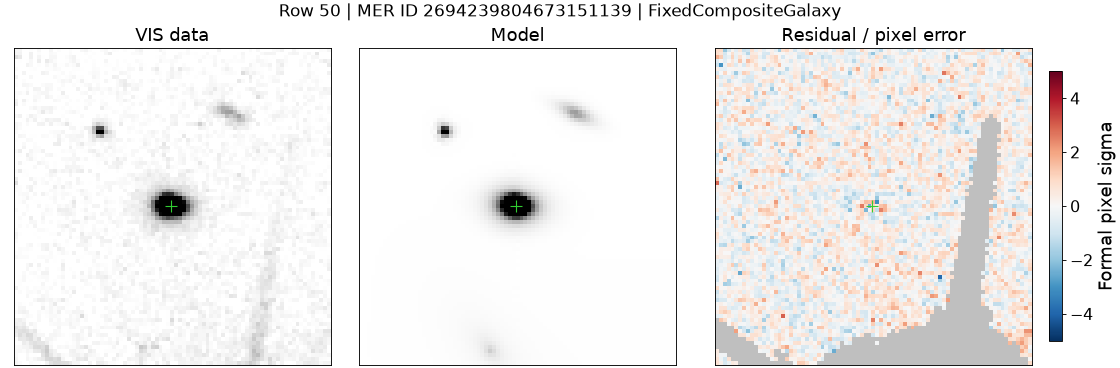

In [15]:
SOURCE_INDEX = 50  # change this number and rerun this cell

if not isinstance(SOURCE_INDEX, (int, np.integer)) or not 0 <= SOURCE_INDEX < len(sources):
    raise ValueError(f"Choose an integer SOURCE_INDEX from 0 to {len(sources) - 1}.")
i = SOURCE_INDEX
quality = flags9

# Crop the existing data and full-scene model; no new fit is performed.
x, y = tim_vis.getWcs().positionToPixel(sources[i].getPosition())
xi, yi, half = int(round(x)), int(round(y)), 40
height, width = res['data'].shape
x0, x1 = max(0, xi - half), min(width, xi + half + 1)
y0, y1 = max(0, yi - half), min(height, yi + half + 1)
stamp = np.s_[y0:y1, x0:x1]
data, model, weight = res['data'][stamp], res['model'][stamp], tim_vis.getInvvar()[stamp]
vmax = max(float(np.nanpercentile(data, 99.5)), np.finfo(float).eps)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
for ax, pixels, title in zip(axes[:2], (data, model), ('VIS data', 'Model')):
    ax.imshow(pixels, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    ax.set_title(title)
ep.viz.show_chi_map(data, model, weight, ax=axes[2], title='Residual / pixel error')
fig.colorbar(axes[2].images[0], ax=axes[2], label='Formal pixel sigma', shrink=0.85)
for ax in axes:
    ax.plot(x - x0, y - y0, '+', color='limegreen', ms=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"Row {i} | MER ID {int(mer_cat['object_id'][i])} | {type(sources[i]).__name__}", fontsize=15)
plt.show()

flags = [name for name in ('bright_star', 'near_bright_star', 'masked', 'edge') if quality[name][i]]
print(f"VIS flux guard passed: {bool(fit_quality[i])}; source flags: {', '.join(flags) or 'none'}")
if measured[i]:
    print(f"VIS fit: {tractor_vis_ujy[i]:.3f} +/- {vis_err_ujy[i]:.3f} microJansky (formal error)")
else:
    print("Flux unconstrained: the stored model amplitude is not a measurement.")
reference = ref_star[i] if is_star[i] else ref_gal[i]
print(f"MER {'PSF' if is_star[i] else 'Sersic'} reference: {reference:.3f} microJansky")


## 12. Empirical calibration of the flux errors

Formal errors treat pixels as independent, while the delivered MER
mosaics contain correlated noise from resampling. We fit point-source
fluxes at empty positions and measure the scatter of flux/error.
This checks the uncertainty scale for that PSF and sample; it does not
validate galaxy-model errors or the covariance of blended fluxes.

The one-call driver performs this check with `calibrate_errors=True`.


VIS: 200 empty positions, flux/err scatter (chi_mad) = 0.792
     formal err median = 0.0075 uJy, empirical sigma = 0.0059 uJy
     adopted inflation = x1.000 (clamped at >= 1; errors are never deflated)


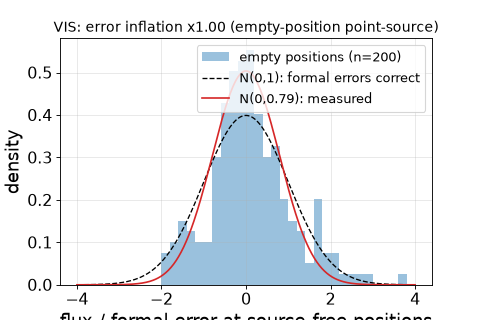

In [16]:
calib_vis = ep.measure_error_inflation(
    cutouts['VIS'], mer_cat=mer_cat, psf_data=psf_data_vis, band='VIS',
    n_positions=200, invvar=tim_vis.getInvvar(), rng=0)
print(f"VIS: {calib_vis['n_positions']} empty positions, "
      f"flux/err scatter (chi_mad) = {calib_vis['chi_mad']:.3f}")
print(f"     formal err median = {calib_vis['formal_err_med_ujy']:.4f} uJy, "
      f"empirical sigma = {calib_vis['empirical_sigma_ujy']:.4f} uJy")
print(f"     adopted inflation = x{calib_vis['inflation']:.3f} "
      f"(clamped at >= 1; errors are never deflated)")

ep.viz.show_error_calibration(calib_vis)
plt.show()

## 13. NISP PSFs

Use the same selected product for Y, J, and H. Each band supplies its own
stamps from the tile used for its science image; each source uses its
nearest sample in that band.


In [17]:
psf_data_nisp = {}
for band in ('Y', 'J', 'H'):
    psf_data_nisp[band] = extract_psf(
        band, TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
        tile_id=cutouts[band].header.get('MERTILE'), data_dir=DATA_DIR / 'psf')
    fwhm = float(np.median(psf_data_nisp[band]['fwhm']))
    print(f"  NISP-{band} {PSF_PRODUCT.upper()}-PSF: {len(psf_data_nisp[band]['stamps'])} stamps, "
          f"median FWHM = {fwhm:.3f} arcsec")


  NISP-Y GRID-PSF: 486 stamps, median FWHM = 0.479 arcsec
  NISP-J GRID-PSF: 486 stamps, median FWHM = 0.503 arcsec
  NISP-H GRID-PSF: 486 stamps, median FWHM = 0.544 arcsec


## 14. Forced photometry in Y, J, and H

Carry the VIS positions and shapes to each NISP band. Render every source
with that band's local PSF and fit all fluxes together, keeping positions
and shapes fixed. The bright-star pixel mask is reused on the common
mosaic grid. It does not identify every band-specific NISP artifact.

Each band also excludes its own invalid and saturated pixels.


In [18]:
t0 = time.time()
nisp_results = ep.fit_nisp_forced(
    sources,
    {b: cutouts[b]        for b in ('Y', 'J', 'H')},
    # Same 0.1 arcsec grid as VIS, so the STARSIGNAL veto carries over.
    pixel_mask=star_mask,
    n_workers=N_WORKERS, psf_data=psf_data_nisp,
)
# fit_nisp_forced returns {band: {"flux_ujy": ..., "flux_err_ujy": ...}}.
# Split into plain per-band arrays the rest of the notebook consumes.
nisp_flux_ujy = {b: nisp_results[b]['flux_ujy']     for b in ('Y', 'J', 'H')}
nisp_err_ujy  = {b: nisp_results[b]['flux_err_ujy'] for b in ('Y', 'J', 'H')}
print(f"NISP forced phot done in {time.time()-t0:.1f} s")
for band in ('Y', 'J', 'H'):
    f = nisp_flux_ujy[band]
    print(f"  {band}: flux range {np.nanmin(f):.2f} - {np.nanmax(f):.0f} microJansky")

NISP forced phot done in 51.8 s
  Y: flux range -36.09 - 1452 microJansky
  J: flux range -57.65 - 1648 microJansky
  H: flux range -53.26 - 1961 microJansky


### NISP versus MER

Compare against MER `flux_<band>_templfit`, measured with T-PHOT.
Its image templates and flux definition differ from our smooth VIS profiles,
so this is a cross-check rather than an exact calibration target.
The panels show flux ratios and magnitude differences for positive fitted
fluxes with formal S/N > 5; medians and NMAD summarize that selected sample.

MER template-fit colors use `FLUX_VIS_TO_<band>_TEMPLFIT` as their VIS
reference; the flux ratios here are not directly color offsets. See the
[MER cookbook](https://euclid.esac.esa.int/dr/q1/dpdd/merdpd/merphotometrycookbook.html).


Y: n=569, median(Tractor/MER_templfit) = 0.968, NMAD(dmag) = 0.124 mag
J: n=701, median(Tractor/MER_templfit) = 0.975, NMAD(dmag) = 0.128 mag
H: n=719, median(Tractor/MER_templfit) = 0.972, NMAD(dmag) = 0.115 mag


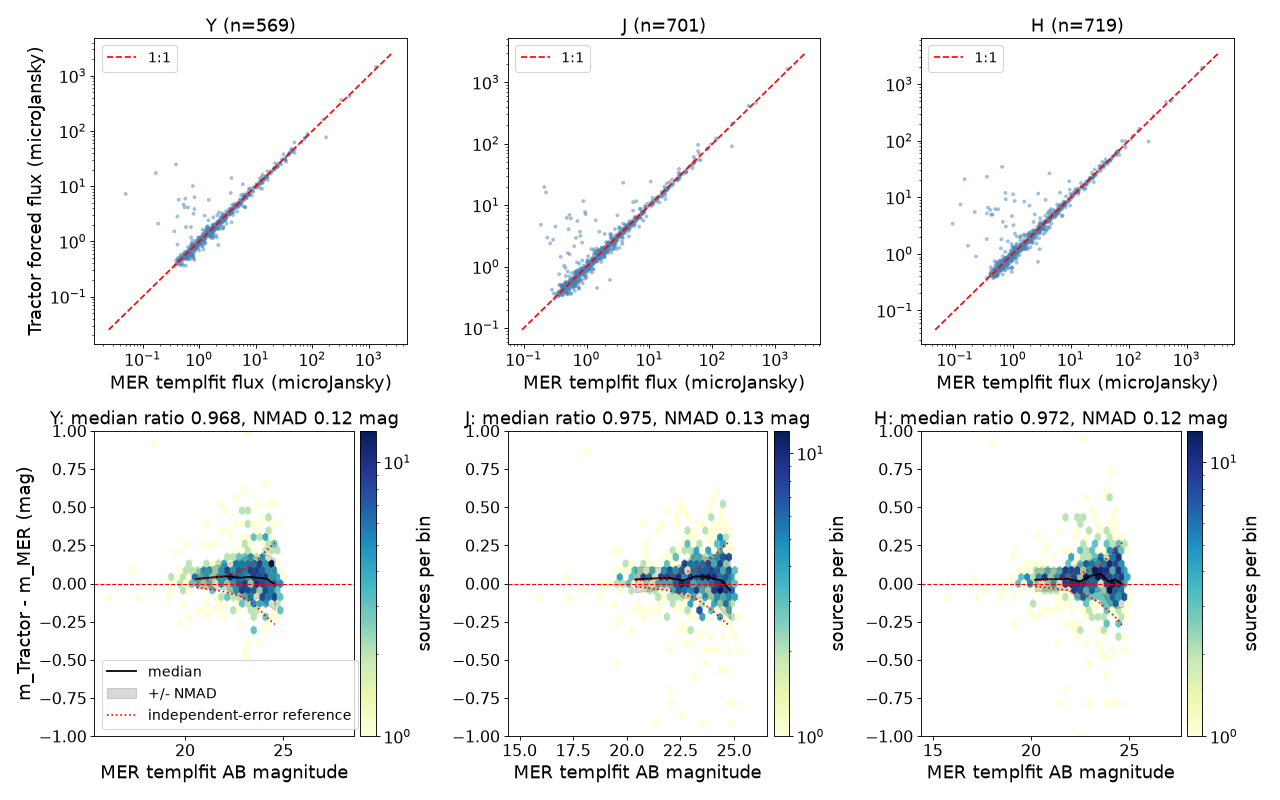

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for col, band in enumerate(('Y', 'J', 'H')):
    ours = np.asarray(nisp_flux_ujy[band], float)
    errs = np.asarray(nisp_err_ujy[band], float)
    ref_n = np.ma.filled(
        np.ma.asarray(mer_cat[f'flux_{band.lower()}_templfit'], float), np.nan)
    with np.errstate(invalid='ignore', divide='ignore'):
        snr = ours / errs
    ok = (fit_quality & np.isfinite(ours) & np.isfinite(ref_n)
          & (ref_n > 0) & (ours > 0) & (snr > 5))

    # Top: flux-flux relation against the 1:1 line.
    axf = axes[0, col]
    axf.scatter(ref_n[ok], ours[ok], s=12, c='steelblue', alpha=0.5,
                edgecolors='none')
    lims = (float(np.nanmin(ref_n[ok])) * 0.5,
            float(np.nanmax(ref_n[ok])) * 2.0)
    axf.plot(lims, lims, 'r--', lw=1.5, label='1:1')
    axf.set_xscale('log'); axf.set_yscale('log')
    axf.set_xlabel('MER templfit flux (microJansky)')
    axf.set_title(f'{band} (n={int(ok.sum())})')
    axf.legend(fontsize=13)

    # Bottom: magnitude difference vs magnitude through the same helper
    # as the VIS comparison in section 10.
    err_n = np.ma.filled(np.ma.asarray(
        mer_cat[f'fluxerr_{band.lower()}_templfit'], float), np.nan)
    med = float(np.median(ours[ok] / ref_n[ok]))
    nmad = float(mad_std(-2.5 * np.log10(ours[ok] / ref_n[ok])))
    ep.viz.show_dmag_vs_mag(
        ref_n, ours, err_ujy=errs, ref_err_ujy=err_n, sel=ok,
        ax=axes[1, col], gridsize=40, max_bins=12,
        xlabel='MER templfit AB magnitude',
        ylabel='m_Tractor - m_MER (mag)' if col == 0 else '',
        title=f'{band}: median ratio {med:.3f}, NMAD {nmad:.2f} mag')
    print(f"{band}: n={int(ok.sum())}, median(Tractor/MER_templfit) = "
          f"{med:.3f}, NMAD(dmag) = {nmad:.3f} mag")
axes[0, 0].set_ylabel('Tractor forced flux (microJansky)')
axes[1, 0].legend(fontsize=13, loc='lower left')
plt.tight_layout(); plt.show()


## 15. unWISE W1/W2 cutouts

The unWISE pixels are 2.75″ across, and the PSF is roughly 6–7″ wide.
Several Euclid sources can therefore contribute to one WISE detection.
We fit their fluxes together on the delivered pixels, with a larger region
around the field to include neighbouring light.

In [20]:
if TARGET_BANDS["wise"]:
    wise_box = max(180.0, float(CUTOUT_SIZE_ARCSEC) + 120.0)
    wise = ep.fetch_unwise_cutouts(
        TARGET_RA, TARGET_DEC, wise_box,
        data_dir=DATA_DIR / 'wise')
    print(f"unWISE box: {wise_box:.0f} arcsec, coadd_id={wise['coadd_id']}")
    print(f"W1 data shape: {wise['W1']['data'].shape}")
    # The 31-bit unWISE bitmask (Meisner 2018) is retrieved per tile from
    # the coadd archive; fit_wise_forced drops the diffraction-spike,
    # halo, and ghost pixels (ep.wise.UNWISE_BAD_BITS) before solving.
    _msk = wise['W1'].get('mask')
    if _msk is not None:
        from euclid_phot.wise import UNWISE_BAD_BITS
        _nbad = int(((_msk & UNWISE_BAD_BITS) != 0).sum())
        print(f"unWISE bitmask: {_nbad} spike/halo/ghost pixel(s) masked in the box")
    else:
        print("unWISE bitmask: not available for this tile (masking skipped)")
else:
    wise = None
    print("TARGET_BANDS['wise'] is empty; skipping unWISE.")


unWISE box: 320 arcsec, coadd_id=2709p666
W1 data shape: (116, 116)
unWISE bitmask: 6 spike/halo/ghost pixel(s) masked in the box


## 16. WISE forced photometry

Keep the VIS positions and shapes fixed, convolve them with the WISE PSF,
evaluated at the field centre, and solve for each WISE flux and a constant
sky together. Include cached
unWISE catalogue sources around the field; a missing catalogue stops the fit.

This assumes that VIS shapes describe the WISE emission. Structured residuals
flag departures from the model; close neighbours can exchange flux even when
the combined model looks reasonable. The reported errors omit blend covariance.
A single PSF describes this small field; remaining spatial PSF variation can
affect blended fluxes, especially near the ecliptic poles.

In this field, stellar epoch offsets and a more compact infrared profile
for galaxy 10 explain part of the structured residuals. Inspect profile and position sensitivity before using individual blended fluxes.


In [21]:
if wise is not None:
    wise_psfs = {band: ep.get_wise_psf(int(band[1]), wise['coadd_id'],
                                            ra=TARGET_RA, dec=TARGET_DEC)
                 for band in TARGET_BANDS['wise']}
    t0 = time.time()
    wise_results = ep.fit_wise_forced(
        sources, wise,
        ra=TARGET_RA, dec=TARGET_DEC,
        cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
        bands=TARGET_BANDS["wise"],
        psf_stamps=wise_psfs, prior_cutout=cutouts['VIS'],
        catalog_cache_dir=DATA_DIR / "wise_catalogs",
        return_model_state=True,  # retain the fitted image and source objects
    )
    print(f"WISE forced phot done in {time.time()-t0:.1f} s")
    for band in TARGET_BANDS["wise"]:
        r = wise_results[band]
        sn = r['flux_ujy'] / np.where(r['flux_err_ujy'] > 0,
                                        r['flux_err_ujy'], np.inf)
        print(f"  {band}: {r['n_supplement_sources']} buffer sources, "
              f"sky={r['sky']:+.3f} nMgy/pix, "
              f"chi inflation={r['chi_inflation']:.2f}, "
              f"S/N>3 in {int(np.nansum(sn > 3))}/{len(sources)} sources")
else:
    wise_results = None


WISE forced phot done in 6.8 s
  W1: 300 buffer sources, sky=-1.398 nMgy/pix, chi inflation=1.91, S/N>3 in 554/1116 sources
  W2: 300 buffer sources, sky=-2.839 nMgy/pix, chi inflation=1.10, S/N>3 in 585/1116 sources


## 17. WISE data, model, and residuals

The full 200″ field in W1 and W2. Data and Model share the same brightness
scale. The residual panels show data minus the complete model, including the
sky; the last column divides each pixel by its delivered error. The fit uses
a larger surrounding region. Inspect an individual source below.

W1: formal sigma = 0.1753 Vega nMgy, chi std = 4.67 (k = 1.91), |chi|>3 = 18.30%, k-pool: source-sparse (|model-sky|<2sigma) (85 pixels)
W2: formal sigma = 0.6261 Vega nMgy, chi std = 1.61 (k = 1.10), |chi|>3 = 4.65%, k-pool: source-sparse (|model-sky|<1sigma) (233 pixels)


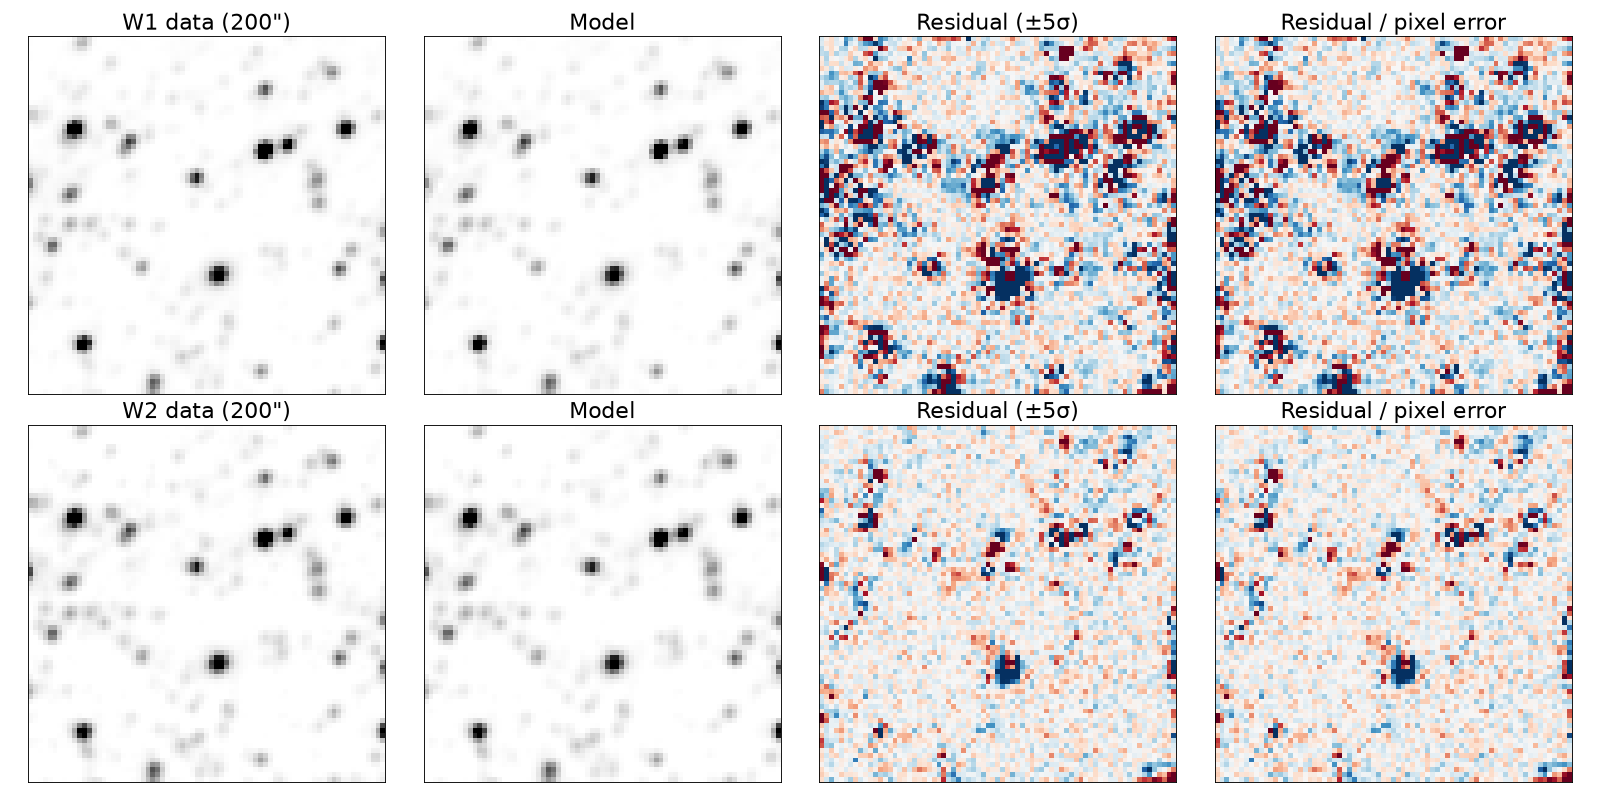

In [22]:
if wise_results is not None:
    from astropy.nddata import Cutout2D
    import astropy.units as u

    bands_to_show = TARGET_BANDS["wise"]
    fig, axes = plt.subplots(len(bands_to_show), 4,
                              figsize=(20, 5 * len(bands_to_show)))
    if len(bands_to_show) == 1:
        axes = axes[np.newaxis, :]
    for row_idx, band in enumerate(bands_to_show):
        r = wise_results[band]
        # Show W1/W2 at the CUTOUT_SIZE_ARCSEC box used for VIS/NISP; the fit
        # uses the full padded region.
        wcs_w = r['wcs']
        cx, cy = wcs_w.world_to_pixel_values(TARGET_RA, TARGET_DEC)
        pos = (float(cx), float(cy))
        box = CUTOUT_SIZE_ARCSEC * u.arcsec
        data = Cutout2D(r['data'], pos, box, wcs=wcs_w,
                        mode='partial', fill_value=0.0).data
        model = Cutout2D(r['model'], pos, box, wcs=wcs_w,
                         mode='partial', fill_value=0.0).data
        invvar = Cutout2D(r['invvar'], pos, box, wcs=wcs_w,
                          mode='partial', fill_value=0.0).data
        vmax = float(np.nanpercentile(data, 99.5))
        axes[row_idx, 0].imshow(data, origin='lower', cmap='gray_r',
                                vmin=0, vmax=vmax)
        axes[row_idx, 0].set_title(f'{band} data ({CUTOUT_SIZE_ARCSEC:.0f}")')
        axes[row_idx, 1].imshow(model, origin='lower', cmap='gray_r',
                                vmin=0, vmax=vmax)
        axes[row_idx, 1].set_title('Model')
        _, info_res = ep.viz.show_residual(
            data, model, invvar=invvar,
            ax=axes[row_idx, 2],
            title='Residual (±5σ)')
        _, info_chi = ep.viz.show_chi_map(
            data, model, invvar,
            ax=axes[row_idx, 3], title='Residual / pixel error')
        for ax in axes[row_idx]:
            ax.set_xticks([]); ax.set_yticks([])
            ax.title.set_fontsize(20)
        print(f"{band}: formal sigma = {info_res['formal_sigma']:.4f} Vega nMgy, "
              f"chi std = {info_chi['chi_std']:.2f} (k = {r['chi_inflation']:.2f}), "
              f"|chi|>3 = {info_chi['pct_chi_gt_3']:.2f}%, "
              f"k-pool: {r['chi_pool_kind']} ({r['n_chi_pool']} pixels)")
    plt.tight_layout(); plt.show()

### Inspect a WISE source

Change `WISE_SOURCE_INDEX` or `WISE_BAND` and rerun the next cell without
refitting. The index follows the Euclid source list. The default pair, sources
65 and 41, is about 3″ apart and shares the same nearest unWISE detection.

Coloured crosses mark their positions, with fitted fluxes labelled below.
**Model** includes all sources and the sky. The residual uses the delivered
pixel errors; coherent patches indicate model mismatch. The division of
blended light is sensitive to the source models.

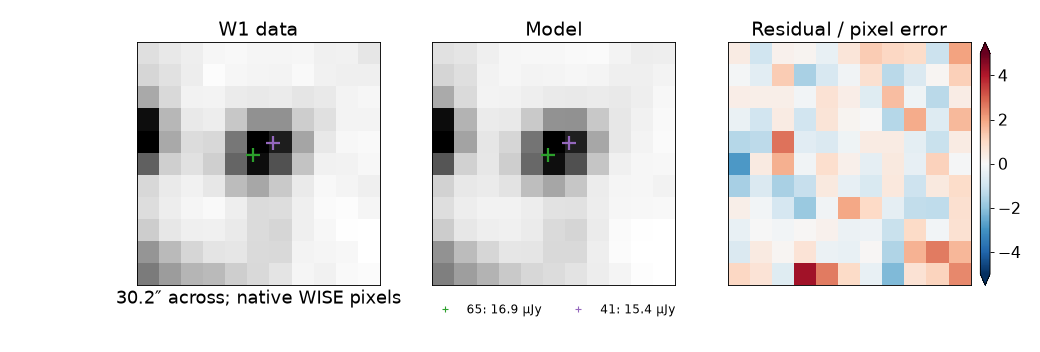

In [23]:
WISE_SOURCE_INDEX = 65  # choose another Euclid source
WISE_BAND = "W1"        # "W1" or "W2"
WISE_SIZE_ARCSEC = 30.0

if wise_results is not None:
    from astropy.nddata import Cutout2D
    import astropy.units as u

    if not isinstance(WISE_SOURCE_INDEX, (int, np.integer)) or not 0 <= WISE_SOURCE_INDEX < len(sources):
        raise ValueError(f"Choose an integer from 0 to {len(sources)-1}")
    r = wise_results[WISE_BAND]
    xy = np.array([r['wcs'].world_to_pixel_values(s.pos.ra, s.pos.dec) for s in sources])
    centre = tuple(xy[WISE_SOURCE_INDEX])
    cut = Cutout2D(r['data'], centre, WISE_SIZE_ARCSEC*u.arcsec, wcs=r['wcs'])
    sy, sx = cut.slices_original
    data, model = r['data'][sy, sx], r['model'][sy, sx]
    weight = r['invvar'][sy, sx]
    chi = np.where(weight > 0, (data-model)*np.sqrt(weight), np.nan)
    extent = (sx.start-.5, sx.stop-.5, sy.start-.5, sy.stop-.5)
    lo, hi = np.nanpercentile(data[weight > 0], [1, 99])
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
    for ax, im, title in zip(axes, (data, model, chi),
                              (f'{WISE_BAND} data', 'Model', 'Residual / pixel error')):
        residual_panel = ax is axes[2]
        shown = ax.imshow(im, origin='lower', extent=extent, interpolation='nearest',
            cmap='RdBu_r' if residual_panel else 'gray_r',
            vmin=-5 if residual_panel else lo, vmax=5 if residual_panel else hi)
        ax.set_title(title, fontsize=17); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(shown, cax=axes[2].inset_axes([1.04, 0, .04, 1]), extend='both')

    # Highlight the selected source and the brightest positive neighbour within one FWHM.
    distance = np.hypot(*(xy-np.asarray(centre)).T)*2.75
    near = np.flatnonzero((distance < 6.94) & (r['flux_ujy'] > 0)
                         & (np.arange(len(sources)) != WISE_SOURCE_INDEX))
    highlight = [WISE_SOURCE_INDEX] + ([near[np.argmax(r['flux_ujy'][near])]] if len(near) else [])
    for j, colour in zip(highlight, ('tab:green', 'tab:purple')):
        for ax in axes[:2]:
            ax.plot(*xy[j], '+', color=colour, ms=12, mew=2)
        axes[1].plot([], [], '+', color=colour, label=f'{j}: {r["flux_ujy"][j]:.1f} μJy')
    axes[1].legend(loc='upper center', bbox_to_anchor=(.5, -.03), ncol=2, fontsize=11, frameon=False)
    axes[0].set_xlabel(f'{data.shape[1]*2.75:.1f}″ across; native WISE pixels')
    plt.subplots_adjust(wspace=.15, bottom=.19, right=.94); plt.show()


## 18. Cross-check against the Schlafly et al. (2019) unWISE catalog

[Schlafly et al. (2019), section 5.3](https://arxiv.org/abs/1901.03337)
normalize their PSF within 19×19 pixels. For this comparison, multiply our
full-stamp fluxes and errors by the central 19×19 fraction of our adopted PSF.
This changes the amplitude convention; it does not determine an absolute
zero point or correct differences in PSF shape. The exported fitted fluxes
retain the full-stamp convention.

Use unique positional matches with valid per-band primary photometry and
no unWISE flags. Highlight sources with no MER neighbour brighter than
one-third of their VIS flux within 14″. This does not ensure WISE isolation.
Image depth, epochs, source lists, and deblending also differ.


In [24]:
WISE_FWHM_ARCSEC = 6.94
MATCH_RADIUS_ARCSEC = 1.0
ISOLATION_RADIUS_ARCSEC = 2 * WISE_FWHM_ARCSEC
ISOLATION_FLUX_FRACTION = 1.0 / 3.0

# Cover the actual image corners, with room for a positional match.
vis_cut = cutouts['VIS']
h, w = vis_cut.shape
corner_ra, corner_dec = vis_cut.wcs.pixel_to_world_values(
    [0, 0, w-1, w-1], [0, h-1, 0, h-1])
query_radius = (SkyCoord(corner_ra, corner_dec, unit='deg').separation(
    SkyCoord(TARGET_RA, TARGET_DEC, unit='deg')).arcsec.max()
    + MATCH_RADIUS_ARCSEC + 1.0)
uw_cat = (ep.query_unwise_2019(TARGET_RA, TARGET_DEC, query_radius,
                              cache_dir=DATA_DIR / "wise_catalogs")
          if wise_results is not None else None)

if uw_cat is not None and len(uw_cat):
    src_coord = SkyCoord([s.getPosition().ra for s in sources],
                         [s.getPosition().dec for s in sources], unit='deg')
    uw_coord = SkyCoord(uw_cat['ra'], uw_cat['dec'], unit='deg')
    idx, sep2d, _ = src_coord.match_to_catalog_sky(uw_coord)
    matched = sep2d.arcsec < MATCH_RADIUS_ARCSEC
    # Exclude detections assigned to more than one Euclid source.
    multiplicity = np.bincount(idx[matched], minlength=len(uw_cat))
    unique_match = matched & (multiplicity[idx] == 1)

    # VIS isolation does not exclude red neighbours bright only in WISE.
    vis_ref = np.where(is_star, ref_star, ref_gal)
    isolated = np.zeros(len(sources), dtype=bool)
    for i in range(len(sources)):
        if not (vis_ref[i] > 0):
            continue
        sep = src_coord[i].separation(src_coord).arcsec
        sep[i] = np.inf
        isolated[i] = not np.any((sep < ISOLATION_RADIUS_ARCSEC) &
            (vis_ref > ISOLATION_FLUX_FRACTION * vis_ref[i]))
    print(f"Schlafly detections: {len(uw_cat)} within {query_radius:.1f} arcsec")
    print(f"Positional matches: {matched.sum()}; unique matches: {unique_match.sum()}")


Schlafly detections: 333 within 143.4 arcsec
Positional matches: 139; unique matches: 121


W1: PSF convention factor=0.95174; VIS-isolated S/N>5 n=26, median flux ratio=1.061; reported error ratio=0.41
W2: PSF convention factor=0.95880; VIS-isolated S/N>5 n=22, median flux ratio=1.031; reported error ratio=0.27


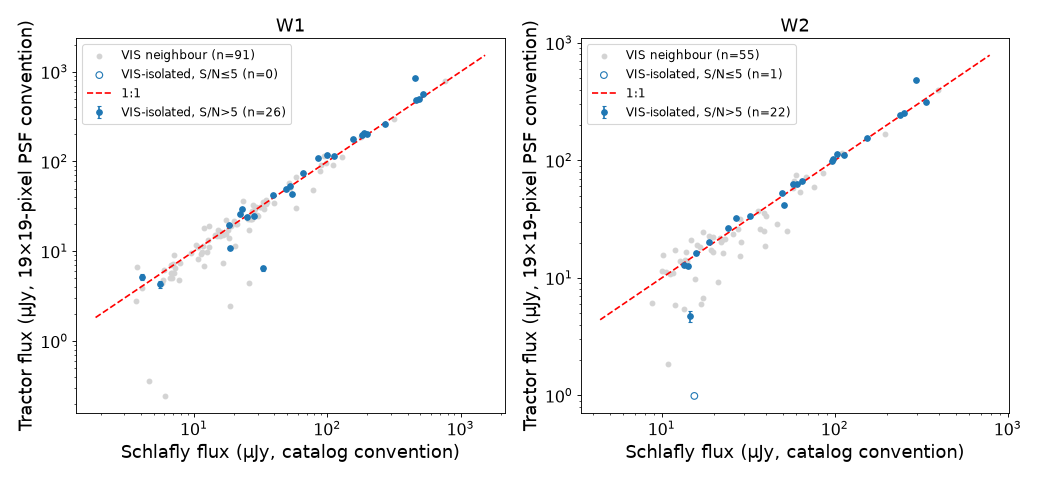

In [25]:
if uw_cat is not None and len(uw_cat) and wise_results is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    wise_comparison = {}
    for ax, band in zip(axes, ('W1', 'W2')):
        # Schlafly normalizes its PSF in the central 19 x 19 pixels.
        # Reparameterize our adopted stamp for this comparison only.
        psf = wise_psfs[band]
        cy, cx = np.array(psf.shape) // 2
        factor = float(psf[cy-9:cy+10, cx-9:cx+10].sum() / psf.sum())
        trac = wise_results[band]['flux_ujy'] * factor
        err = wise_results[band]['flux_err_ujy'] * factor
        ref = np.asarray(uw_cat[band.lower() + '_ujy'], float)[idx]
        ref_err = np.asarray(uw_cat[band.lower() + '_err_ujy'], float)[idx]
        primary = np.asarray(np.ma.filled(uw_cat['primary_' + band[1]], 0))[idx] == 1
        unflagged = np.asarray(np.ma.filled(uw_cat['flags_unwise_' + band[1]], -1))[idx] == 0
        sn = np.divide(trac, err, out=np.zeros_like(trac), where=err > 0)
        selected = (unique_match & primary & unflagged & fit_quality
                    & np.isfinite(trac) & (trac > 0) & np.isfinite(err) & (err > 0)
                    & np.isfinite(ref) & (ref > 0) & np.isfinite(ref_err) & (ref_err > 0))
        hi = selected & isolated & (sn > 5)
        low = selected & isolated & ~hi
        crowded = selected & ~isolated
        ax.scatter(ref[crowded], trac[crowded], color='lightgray', s=18,
                   label=f'VIS neighbour (n={crowded.sum()})')
        ax.scatter(ref[low], trac[low], facecolors='none', edgecolors='C0', s=36,
                   label=f'VIS-isolated, S/N≤5 (n={low.sum()})')
        ax.errorbar(ref[hi], trac[hi], yerr=err[hi], fmt='o', color='C0', ms=5,
                    capsize=2, label=f'VIS-isolated, S/N>5 (n={hi.sum()})')
        if selected.any():
            limits = [ref[selected].min() * 0.5, ref[selected].max() * 2]
            ax.plot(limits, limits, 'r--', label='1:1')
        ax.set(xscale='log', yscale='log', title=band,
               xlabel='Schlafly flux (µJy, catalog convention)',
               ylabel='Tractor flux (µJy, 19×19-pixel PSF convention)')
        ax.legend(fontsize=11)
        median = float(np.median(trac[hi] / ref[hi])) if hi.any() else np.nan
        error_ratio = float(np.median(err[hi] / ref_err[hi])) if hi.any() else np.nan
        wise_comparison[band] = dict(psf_factor=factor, n=int(hi.sum()),
                                    median_ratio=median, error_ratio=error_ratio)
        print(f"{band}: PSF convention factor={factor:.5f}; "
              f"VIS-isolated S/N>5 n={hi.sum()}, median flux ratio={median:.3f}; "
              f"reported error ratio={error_ratio:.2f}")
    plt.tight_layout(); plt.show()
else:
    print("Schlafly comparison skipped (WISE disabled or no catalog rows).")


*The medians describe the VIS-isolated, fitted S/N > 5 sample. Ratios of
reported errors compare scales; they do not validate either error estimate.*


## 19. The multi-band catalog

`ForcedPhotometryResult.to_table()` creates one row per source with flux
density, estimated uncertainty, AB magnitude, model class, and quality flags.
Flux densities are in microJansky, with `m_AB = 23.9 - 2.5 log10(flux_uJy)`
for positive fluxes. Non-positive fluxes have no ordinary AB magnitude;
zero-information measurements are exported as NaN. Large finite errors can
still indicate weak constraints. `reliable` covers geometric VIS checks,
not fit convergence or blending in every band. Rows failing the VIS flux
guard are excluded in all bands, making this a VIS-selected catalog.

Extinction-corrected magnitudes use an approximate Galactic foreground
law; observed fluxes are unchanged. The coefficients and dust-map source
are recorded in the table metadata.


In [26]:
from euclid_phot import ForcedPhotometryResult

# Collect the per-band fluxes and errors measured above into the same result
# object the one-call driver returns, then let it assemble the catalog.
fluxes = {'VIS': tractor_vis_ujy}
errors = {'VIS': vis_err_ujy}
for band in ('Y', 'J', 'H'):
    fluxes[band] = nisp_flux_ujy[band]
    errors[band] = nisp_err_ujy[band]
if wise_results is not None:
    for band in TARGET_BANDS['wise']:
        fluxes[band] = wise_results[band]['flux_ujy']
        errors[band] = wise_results[band]['flux_err_ujy']

# Exclude rows that failed the VIS flux guard from this output catalog.
for band in fluxes:
    fluxes[band] = np.where(fit_quality, fluxes[band], np.nan)
    errors[band] = np.where(fit_quality, errors[band], np.nan)

result = ForcedPhotometryResult(
    target=(TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC),
    prior=dict(PRIOR), target_bands=dict(TARGET_BANDS),
    mer_cat=mer_cat, sources=sources,
    cutouts=cutouts,
    psf_data={"VIS": psf_data_vis, **psf_data_nisp},
    psf_mode="nearest-source-position",
    prior_pixel_mask=star_mask,
    fluxes_ujy=fluxes, flux_errs_ujy=errors,
    flux_quality=fit_quality, wise_results=wise_results,
    chosen_models=[type(s).__name__ for s in sources],
    data_dir=DATA_DIR,
)

# Empirical error calibration (section 12) for every Euclid band; the
# factors multiply the errors in place and land in the table metadata.
ep.calibrate_result_errors(result, verbose=True)

# Add quality flags, Galactic-extinction corrections, and error summaries.
catalog = result.to_table()
out_path = Path('forced_photometry_catalog.ecsv')
catalog.write(out_path, overwrite=True)
print(f"\nwrote {len(catalog)} sources x {len(catalog.colnames)} columns "
      f"to {out_path.resolve()}")
print(f"error inflation: {catalog.meta['error_inflation']}")
print(f"5 × median-error equivalents (AB): {catalog.meta['depth_5sigma_ab']}")
print(f"E(B-V) source: {catalog.meta['extinction']['ebv_source']}")

# Preview the eight brightest measured sources passing the VIS flux guard.
cols = ['object_id', 'ra', 'dec', 'model', 'flux_quality',
        'flux_VIS_ujy', 'mag_VIS_ab', 'mag_VIS_ab_extcorr', 'mag_H_ab',
        'blended', 'reliable']
if 'mag_W1_ab' in catalog.colnames:
    cols.append('mag_W1_ab')
mask = (np.asarray(catalog['flux_quality'])
        & np.isfinite(np.asarray(catalog['mag_VIS_ab'])))
preview = catalog[mask].copy()
preview.sort('flux_VIS_ujy')
preview[cols][-8:].pprint_all()


  VIS: error inflation x1.00 (empty-position point-source, n=200)
  Y: error inflation x1.07 (empty-position point-source, n=200)
  J: error inflation x1.00 (empty-position point-source, n=200)
  H: error inflation x1.00 (empty-position point-source, n=199)

wrote 1116 sources x 52 columns to <project>/notebooks/forced_photometry_catalog.ecsv
error inflation: {'VIS': 1.0, 'Y': 1.0694, 'J': 1.0, 'H': 1.0}
5 × median-error equivalents (AB): {'VIS': 26.456, 'Y': 24.447, 'J': 24.589, 'H': 24.504, 'W1': 23.082, 'W2': 22.862}
E(B-V) source: MER gal_ebv (Planck R1.20, per source)
     object_id              ra                dec               model         flux_quality    flux_VIS_ujy        mag_VIS_ab     mag_VIS_ab_extcorr      mag_H_ab      blended reliable     mag_W1_ab     
                           deg                deg                                                 uJy                mag                mag                mag                                 mag        
--------------